# Copernicus Solar Forecasting - notebook hybride VSCode / Colab

Ce notebook sert a separer proprement les executions:

- VSCode / local: baselines, features, clustering, modeles tabulaires.
- Google Colab: deep learning, notamment ConvLSTM si TensorFlow/GPU est disponible.
- Final: rechargement de tous les outputs sauvegardes et comparaison unique.

Le principe est simple: chaque run sauvegarde ses predictions dans un dossier commun. La comparaison finale recharge les predictions et recalcule les metriques avec le meme `val_target`.

## 0. Choisir le mode d'execution

Regler les flags selon l'environnement:

- Dans VSCode: `RUN_LOCAL_MODELS=True`, `RUN_DEEP_LEARNING=False`, `LOAD_SAVED_OUTPUTS=True`.
- Dans Colab: `RUN_LOCAL_MODELS=False`, `RUN_DEEP_LEARNING=True`, `SAVE_OUTPUTS=True`.
- Pour le rendu final: `RUN_LOCAL_MODELS=False`, `RUN_DEEP_LEARNING=False`, `LOAD_SAVED_OUTPUTS=True`.

Important: Colab et VSCode doivent utiliser le meme `PROFILE`, le meme split chronologique et le meme dossier d'artefacts.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from config import FORECAST_HORIZONS_MINUTES, INPUT_VARIABLES
from src.baselines import mean_image_baseline, persistence_csi_baseline, persistence_last_ghi_baseline
from src.data_loading import open_processed_profile, prepare_processed_profile, processed_profile_exists
from src.deep_learning import (
    add_residual_mean_to_baseline,
    build_convlstm_residual_model,
    fit_mlp_residual_mean,
    has_tensorflow,
    prepare_convlstm_training_data,
    target_from_channels_last,
)
from src.eda import descriptive_stats, target_horizon_stats
from src.experiment_io import (
    diagnostics_from_saved_outputs,
    list_saved_outputs,
    load_saved_predictions,
    save_prediction_bundle,
)
from src.features import (
    build_advanced_features,
    build_exogenous_features,
    build_physical_inputs,
    build_spatial_feature_tensor,
    build_tabular_features,
)
from src.metrics import (
    build_model_diagnostics,
    cluster_balance_report,
    cluster_quality,
    global_metrics_row,
    metrics_by_cluster,
    rmse,
    spatial_mean_residual,
)
from src.motion import advective_csi_baseline, estimate_motion_vectors, has_opencv
from src.preprocessing import temporal_train_validation_split
from src.texture import build_texture_features
from src.visualization import horizon_titles, plot_sequence
from models.models_tabular import (
    fit_elasticnet_multioutput,
    fit_extra_trees_multioutput,
    fit_hist_gb_multioutput,
    fit_random_forest_multioutput,
    fit_ridge_multioutput,
    patchwise_predictions_to_map,
    patchwise_target_means,
)

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
RANDOM_STATE = 42
PROFILE = "full"  # "dev" pour test rapide, "sample" ou "full" pour rendu final
MAIN_REFERENCE_NAME = "persistence_csi"

# Modes d'execution.
RUN_LOCAL_MODELS = True
RUN_DEEP_LEARNING = False
RUN_CLUSTERING = True

# Sauvegarde / chargement des outputs.
SAVE_OUTPUTS = True
LOAD_SAVED_OUTPUTS = True
OVERWRITE_OUTPUTS = True

# Dans VSCode, ce dossier est dans le repo.
OUTPUT_DIR = ROOT / "reports" / "model_outputs" / PROFILE

# Dans Colab, decommente ce bloc et pointe vers Google Drive.
# from google.colab import drive
# drive.mount("/content/drive")
# OUTPUT_DIR = Path("/content/drive/MyDrive/copernicus_model_outputs") / PROFILE

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("ROOT:", ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)
np.random.seed(RANDOM_STATE)

ROOT: c:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Machine Learning\projet\copernicus_solar_forecasting
OUTPUT_DIR: c:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Machine Learning\projet\copernicus_solar_forecasting\reports\model_outputs\full


## 1. Chargement des donnees et split commun

Tous les environnements doivent recreer exactement le meme split. Ici on utilise `temporal_train_validation_split`, donc il suffit de garder le meme `PROFILE` et la meme fraction de validation.

In [3]:
if not processed_profile_exists(PROFILE, split="train"):
    prepare_processed_profile(PROFILE, split="train", overwrite=False)

data = open_processed_profile(PROFILE, split="train", variables=INPUT_VARIABLES, mmap_mode=None)
arrays = {name: np.asarray(values, dtype=np.float32) for name, values in data["X"].items()}
y = np.asarray(data["y"], dtype=np.float32)

train_idx, val_idx = temporal_train_validation_split(len(y), validation_fraction=0.2)
train_arrays_raw = {name: values[train_idx] for name, values in arrays.items()}
val_arrays_raw = {name: values[val_idx] for name, values in arrays.items()}
train_target = y[train_idx]
val_target = y[val_idx]

print(f"Profil: {PROFILE}")
print(f"Samples: total={len(y)}, train={len(train_idx)}, validation={len(val_idx)}")
print({name: value.shape for name, value in arrays.items()})
print("Target:", y.shape)

available_variables = sorted(arrays)
wind_variables = [name for name in available_variables if name.lower() in {"u", "v", "u10", "v10", "wind_u", "wind_v"}]
print("Variables vent detectees:" if wind_variables else "Variables vent absentes:", wind_variables)

Profil: full
Samples: total=1845, train=1476, validation=369
{'GHI': (1845, 4, 51, 51), 'CLS': (1845, 8, 51, 51), 'SZA': (1845, 8, 51, 51), 'SAA': (1845, 8, 51, 51)}
Target: (1845, 4, 51, 51)
Variables vent absentes: []


## 2. Baselines communes

Les baselines sont recalculees partout, car elles sont rapides et garantissent que Colab et VSCode travaillent sur le meme `val_target`.

In [4]:
y_pred_persistence_raw = persistence_last_ghi_baseline(val_arrays_raw)
y_pred_persistence_csi = persistence_csi_baseline(val_arrays_raw)
y_pred_mean = mean_image_baseline(train_target, n_samples=len(val_target))
y_pred_train_csi = persistence_csi_baseline(train_arrays_raw)

baseline_predictions = {
    "persistence_raw": y_pred_persistence_raw,
    "persistence_csi": y_pred_persistence_csi,
    "mean_image": y_pred_mean,
}

baseline_diagnostics = build_model_diagnostics(
    val_target,
    baseline_predictions,
    reference_name=MAIN_REFERENCE_NAME,
)
display(baseline_diagnostics["global"])

,model,RMSE,MAE,MBE,MedAE,P90AE,nRMSE,R2,MAPE,corr_spatial_mean,skill_RMSE_vs_CSI
0,persistence_csi,44.068412,24.736332,-3.736546,9.424938,68.010527,0.132801,0.934491,10.857473,0.994194,5.149214e-12
1,persistence_raw,83.515920,65.760217,0.345245,50.570007,144.649994,0.251677,0.764721,29.931432,0.893965,-2.591565e+00
2,mean_image,282.065124,241.754936,223.349541,232.432251,445.568024,0.850010,-1.683758,161.744619,0.019122,-3.996793e+01


## 3. Features tabulaires, mouvement et texture

Cette section est utile pour les modeles locaux. Colab peut aussi l'executer si le DL utilise les memes features tabulaires comme fallback MLP.

In [5]:
train_phys = build_physical_inputs(train_arrays_raw, keep_raw_ghi=True, encode_angles=True)
val_phys = build_physical_inputs(val_arrays_raw, keep_raw_ghi=True, encode_angles=True)

feature_blocks_train = [
    build_tabular_features(train_phys).add_prefix("phys_"),
    build_advanced_features(train_arrays_raw).add_prefix("adv_"),
]
feature_blocks_val = [
    build_tabular_features(val_phys).add_prefix("phys_"),
    build_advanced_features(val_arrays_raw).add_prefix("adv_"),
]

train_motion_features = estimate_motion_vectors(train_phys["CSI"], use_farneback=None).add_prefix("flow_")
val_motion_features = estimate_motion_vectors(val_phys["CSI"], use_farneback=None).add_prefix("flow_")
feature_blocks_train.append(train_motion_features)
feature_blocks_val.append(val_motion_features)
print("Optical flow:", "Farneback/OpenCV" if has_opencv() else "phase-correlation + barycentre fallback")

train_texture_features = build_texture_features(train_phys, variable="CSI", time_index=-1).add_prefix("tex_")
val_texture_features = build_texture_features(val_phys, variable="CSI", time_index=-1).add_prefix("tex_")
feature_blocks_train.append(train_texture_features)
feature_blocks_val.append(val_texture_features)

train_exogenous_features = build_exogenous_features(train_arrays_raw).add_prefix("exo_")
val_exogenous_features = build_exogenous_features(val_arrays_raw).add_prefix("exo_")
if len(train_exogenous_features.columns):
    feature_blocks_train.append(train_exogenous_features)
    feature_blocks_val.append(val_exogenous_features)

X_train_features = pd.concat(feature_blocks_train, axis=1)
X_val_features = pd.concat(feature_blocks_val, axis=1)

common_cols = [col for col in X_train_features.columns if col in X_val_features.columns]
X_train_features = X_train_features[common_cols].replace([np.inf, -np.inf], np.nan)
X_val_features = X_val_features[common_cols].replace([np.inf, -np.inf], np.nan)
medians = X_train_features.median(numeric_only=True).fillna(0.0)
X_train_features = X_train_features.fillna(medians)
X_val_features = X_val_features.fillna(medians)

scaler = StandardScaler()
X_train_tab = scaler.fit_transform(X_train_features).astype(np.float32)
X_val_tab = scaler.transform(X_val_features).astype(np.float32)
feature_names = list(X_train_features.columns)

y_pred_advective_csi = advective_csi_baseline(
    val_arrays_raw,
    motion_features=val_motion_features.rename(columns=lambda col: col.replace("flow_", "")),
)
y_pred_train_advective_csi = advective_csi_baseline(
    train_arrays_raw,
    motion_features=train_motion_features.rename(columns=lambda col: col.replace("flow_", "")),
)

print("Feature matrix:", X_train_tab.shape)
display(X_train_features.describe().T.head(20))

Optical flow: phase-correlation + barycentre fallback
Feature matrix: (1476, 610)


,count,mean,std,min,25%,50%,75%,max
phys_CSI_mean_t0,1476.0,0.880412,0.124901,0.143136,0.846034,0.921615,0.964935,1.002780
phys_CSI_std_t0,1476.0,0.082471,0.069276,0.001421,0.024556,0.063255,0.127203,0.317049
phys_CSI_min_t0,1476.0,0.527376,0.259031,0.093864,0.292224,0.536363,0.757906,0.982073
phys_CSI_max_t0,1476.0,0.964526,0.043581,0.446953,0.957681,0.976410,0.991968,1.020442
phys_CSI_mean_t1,1476.0,0.880345,0.128423,0.147248,0.844999,0.922198,0.965784,1.002667
phys_CSI_std_t1,1476.0,0.084777,0.071150,0.001376,0.024935,0.064601,0.132382,0.322224
phys_CSI_min_t1,1476.0,0.520147,0.266480,0.094576,0.268508,0.535634,0.752697,0.981175
phys_CSI_max_t1,1476.0,0.967008,0.039864,0.475089,0.956523,0.976917,0.991954,1.019928
phys_CSI_mean_t2,1476.0,0.881551,0.128337,0.153504,0.848248,0.922083,0.965704,1.002711
phys_CSI_std_t2,1476.0,0.085331,0.071600,0.001110,0.025301,0.066161,0.131844,0.316081


## 4. Entrainement local VSCode

A executer dans VSCode ou localement. Les predictions sont sauvegardees si `SAVE_OUTPUTS=True`.

In [6]:
local_predictions = {}

if RUN_LOCAL_MODELS:
    local_predictions["advective_csi"] = y_pred_advective_csi

    residual_train = spatial_mean_residual(train_target, y_pred_train_csi)
    residual_val = spatial_mean_residual(val_target, y_pred_persistence_csi)

    ridge_model = fit_ridge_multioutput(X_train_tab, residual_train, alpha=10.0, random_state=RANDOM_STATE)
    local_predictions["ridge_residual_csi"] = add_residual_mean_to_baseline(
        y_pred_persistence_csi,
        ridge_model.predict(X_val_tab),
    )

    rf_model = fit_random_forest_multioutput(
        X_train_tab,
        residual_train,
        n_estimators=30 if PROFILE == "dev" else 150,
        max_depth=6 if PROFILE == "dev" else None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
    )
    local_predictions["random_forest_residual_csi"] = add_residual_mean_to_baseline(
        y_pred_persistence_csi,
        rf_model.predict(X_val_tab),
    )

    extra_model = fit_extra_trees_multioutput(
        X_train_tab,
        residual_train,
        n_estimators=40 if PROFILE == "dev" else 200,
        max_depth=8 if PROFILE == "dev" else None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
    )
    local_predictions["extra_trees_residual_csi"] = add_residual_mean_to_baseline(
        y_pred_persistence_csi,
        extra_model.predict(X_val_tab),
    )

    hgb_model = fit_hist_gb_multioutput(
        X_train_tab,
        residual_train,
        learning_rate=0.1 if PROFILE == "dev" else 0.05,
        max_iter=40 if PROFILE == "dev" else 200,
        max_leaf_nodes=15,
        min_samples_leaf=5 if PROFILE == "dev" else 20,
        l2_regularization=0.0,
        random_state=RANDOM_STATE,
    )
    local_predictions["hist_gb_residual_csi"] = add_residual_mean_to_baseline(
        y_pred_persistence_csi,
        hgb_model.predict(X_val_tab),
    )

    diagnostics_local = build_model_diagnostics(
        val_target,
        {**baseline_predictions, **local_predictions},
        reference_name=MAIN_REFERENCE_NAME,
    )
    display(diagnostics_local["global"])

    if SAVE_OUTPUTS:
        manifest_local = save_prediction_bundle(
            {**baseline_predictions, **local_predictions},
            y_true=val_target,
            output_dir=OUTPUT_DIR,
            profile=PROFILE,
            backend="vscode",
            reference_name=MAIN_REFERENCE_NAME,
            extra_metadata={
                "train_size": int(len(train_idx)),
                "validation_size": int(len(val_idx)),
                "note": "Outputs produits localement / VSCode.",
            },
            overwrite=OVERWRITE_OUTPUTS,
        )
        display(manifest_local)
else:
    print("RUN_LOCAL_MODELS=False: section locale sautee.")

Exception in thread Thread-64 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\alixg\anaconda3\envs\copernicus-solar-dl\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\Users\alixg\anaconda3\envs\copernicus-solar-dl\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\alixg\anaconda3\envs\copernicus-solar-dl\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0x82 in position 101: invalid start byte


,model,RMSE,MAE,MBE,MedAE,P90AE,nRMSE,R2,MAPE,corr_spatial_mean,skill_RMSE_vs_CSI
0,extra_trees_residual_csi,42.551652,23.737721,-2.567757,9.578239,65.135620,0.128230,0.938923,10.762935,0.996644,6.765199e-02
1,hist_gb_residual_csi,42.734920,24.181061,-2.486968,10.412018,65.573784,0.128783,0.938396,11.110652,0.996390,5.960355e-02
2,random_forest_residual_csi,42.748563,24.007016,-2.086447,10.121777,65.470810,0.128824,0.938356,11.009312,0.996303,5.900301e-02
3,ridge_residual_csi,42.955433,25.222888,-0.930622,12.204468,66.020191,0.129447,0.937758,11.979182,0.995852,4.987357e-02
4,persistence_csi,44.068412,24.736332,-3.736546,9.424938,68.010527,0.132801,0.934491,10.857473,0.994194,5.149214e-12
5,advective_csi,49.572551,27.820193,-3.432155,10.741379,76.496201,0.149388,0.917105,12.262212,0.994425,-2.653997e-01
6,persistence_raw,83.515920,65.760217,0.345245,50.570007,144.649994,0.251677,0.764721,29.931432,0.893965,-2.591565e+00
7,mean_image,282.065124,241.754936,223.349541,232.432251,445.568024,0.850010,-1.683758,161.744619,0.019122,-3.996793e+01


,model,backend,predictions,metadata
0,persistence_raw,vscode,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...
1,persistence_csi,vscode,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...
2,mean_image,vscode,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...
3,advective_csi,vscode,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...
4,ridge_residual_csi,vscode,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...
5,random_forest_residual_csi,vscode,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...
6,extra_trees_residual_csi,vscode,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...
7,hist_gb_residual_csi,vscode,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...


## 5. Deep Learning Colab

A executer sur Colab. Le modele ConvLSTM apprend des cartes de residus par rapport a `persistence_csi`. Si TensorFlow n'est pas disponible, le notebook garde un MLP fallback, mais pour Colab l'objectif est bien d'obtenir `convlstm_residual_csi_fullmap`.

In [7]:
dl_predictions = {}

if RUN_DEEP_LEARNING:
    residual_train = spatial_mean_residual(train_target, y_pred_train_csi)

    mlp_model = fit_mlp_residual_mean(
        X_train_tab,
        residual_train,
        hidden_layer_sizes=(64, 32),
        random_state=RANDOM_STATE,
        max_iter=80 if PROFILE == "dev" else 300,
    )
    dl_predictions["mlp_residual_csi"] = add_residual_mean_to_baseline(
        y_pred_persistence_csi,
        mlp_model.predict(X_val_tab),
    )

    X_train_convlstm, y_train_convlstm, convlstm_channels = prepare_convlstm_training_data(
        train_arrays_raw,
        train_target,
        baseline=y_pred_train_csi,
    )
    X_val_convlstm, y_val_convlstm, _ = prepare_convlstm_training_data(
        val_arrays_raw,
        val_target,
        baseline=y_pred_persistence_csi,
    )
    print("ConvLSTM input:", X_train_convlstm.shape, "| channels:", convlstm_channels)

    if has_tensorflow():
        convlstm_model = build_convlstm_residual_model(
            input_shape=X_train_convlstm.shape[1:],
            n_horizons=len(FORECAST_HORIZONS_MINUTES),
            learning_rate=1e-3,
        )
        history = convlstm_model.fit(
            X_train_convlstm,
            y_train_convlstm,
            validation_data=(X_val_convlstm, y_val_convlstm),
            epochs=3 if PROFILE == "dev" else 25,
            batch_size=4 if PROFILE == "dev" else 16,
            verbose=1,
        )
        residual_pred_val = target_from_channels_last(convlstm_model.predict(X_val_convlstm, verbose=0))
        dl_predictions["convlstm_residual_csi_fullmap"] = np.maximum(
            y_pred_persistence_csi + residual_pred_val,
            0.0,
        )
    else:
        print("TensorFlow indisponible: ConvLSTM non executee.")

    diagnostics_dl = build_model_diagnostics(
        val_target,
        {**baseline_predictions, **dl_predictions},
        reference_name=MAIN_REFERENCE_NAME,
    )
    display(diagnostics_dl["global"])

    if SAVE_OUTPUTS:
        manifest_dl = save_prediction_bundle(
            {**baseline_predictions, **dl_predictions},
            y_true=val_target,
            output_dir=OUTPUT_DIR,
            profile=PROFILE,
            backend="colab",
            reference_name=MAIN_REFERENCE_NAME,
            extra_metadata={
                "train_size": int(len(train_idx)),
                "validation_size": int(len(val_idx)),
                "note": "Outputs produits sur Google Colab.",
            },
            overwrite=OVERWRITE_OUTPUTS,
        )
        display(manifest_dl)
else:
    print("RUN_DEEP_LEARNING=False: section DL sautee.")

RUN_DEEP_LEARNING=False: section DL sautee.


## 6. Verifier les artefacts sauvegardes

Cette cellule liste ce qui est disponible dans le dossier commun.

In [8]:
saved_listing = list_saved_outputs(OUTPUT_DIR)
display(saved_listing)

,model,slug,backend,profile,prediction_shape,created_at_utc,predictions_path,metadata_path,exists
0,advective_csi,advective_csi,vscode,full,"(369, 4, 51, 51)",2026-04-17T16:11:18.377396+00:00,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...,True
1,extra_trees_residual_csi,extra_trees_residual_csi,vscode,full,"(369, 4, 51, 51)",2026-04-17T16:11:25.054301+00:00,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...,True
2,hist_gb_residual_csi,hist_gb_residual_csi,vscode,full,"(369, 4, 51, 51)",2026-04-17T16:11:28.532039+00:00,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...,True
3,mean_image,mean_image,vscode,full,"(369, 4, 51, 51)",2026-04-17T16:11:17.060050+00:00,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...,True
4,persistence_csi,persistence_csi,vscode,full,"(369, 4, 51, 51)",2026-04-17T16:11:15.325362+00:00,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...,True
5,persistence_raw,persistence_raw,vscode,full,"(369, 4, 51, 51)",2026-04-17T16:11:13.962188+00:00,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...,True
6,random_forest_residual_csi,random_forest_residual_csi,vscode,full,"(369, 4, 51, 51)",2026-04-17T16:11:22.514158+00:00,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...,True
7,ridge_residual_csi,ridge_residual_csi,vscode,full,"(369, 4, 51, 51)",2026-04-17T16:11:19.821764+00:00,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...,True


## 7. Comparaison finale depuis les outputs sauvegardes

Cette section est celle a conserver pour le rendu: elle recharge toutes les predictions sauvegardees, ajoute au besoin les baselines recalculees, et refait les tableaux de comparaison.

Predictions chargees: ['advective_csi', 'extra_trees_residual_csi', 'hist_gb_residual_csi', 'mean_image', 'persistence_csi', 'persistence_raw', 'random_forest_residual_csi', 'ridge_residual_csi']


,model,RMSE,MAE,MBE,MedAE,P90AE,nRMSE,R2,MAPE,corr_spatial_mean,skill_RMSE_vs_CSI
0,extra_trees_residual_csi,42.551652,23.737721,-2.567757,9.578239,65.135620,0.128230,0.938923,10.762935,0.996644,6.765199e-02
1,hist_gb_residual_csi,42.734920,24.181061,-2.486968,10.412018,65.573784,0.128783,0.938396,11.110652,0.996390,5.960355e-02
2,random_forest_residual_csi,42.748563,24.007016,-2.086447,10.121777,65.470810,0.128824,0.938356,11.009312,0.996303,5.900301e-02
3,ridge_residual_csi,42.955433,25.222888,-0.930622,12.204468,66.020191,0.129447,0.937758,11.979182,0.995852,4.987357e-02
4,persistence_csi,44.068412,24.736332,-3.736546,9.424938,68.010527,0.132801,0.934491,10.857473,0.994194,5.149214e-12
5,advective_csi,49.572551,27.820193,-3.432155,10.741379,76.496201,0.149388,0.917105,12.262212,0.994425,-2.653997e-01
6,persistence_raw,83.515920,65.760217,0.345245,50.570007,144.649994,0.251677,0.764721,29.931432,0.893965,-2.591565e+00
7,mean_image,282.065124,241.754936,223.349541,232.432251,445.568024,0.850010,-1.683758,161.744619,0.019122,-3.996793e+01


,horizon_min,RMSE,MAE,bias,P90AE,corr_spatial_mean,skill_RMSE_vs_ref,skill_MAE_vs_ref,model
16,15,20.879810,12.256272,-1.707617,33.769759,0.999410,3.165220e-02,3.090682e-02,extra_trees_residual_csi
20,15,20.948792,12.448852,-1.757963,33.842540,0.999371,2.845304e-02,1.567965e-02,hist_gb_residual_csi
24,15,20.951002,12.355224,-1.535589,33.895091,0.999338,2.835054e-02,2.308277e-02,random_forest_residual_csi
28,15,21.146440,13.048861,-1.050944,33.887012,0.999146,1.928667e-02,-3.176252e-02,ridge_residual_csi
4,15,21.562305,12.647155,-1.998343,35.052832,0.998831,4.637724e-10,7.906917e-10,persistence_csi
12,15,26.843404,15.103280,-1.811409,41.202304,0.998899,-2.449228e-01,-1.942037e-01,advective_csi
0,15,34.233336,28.551074,-2.447420,50.460022,0.984782,-5.876473e-01,-1.257509e+00,persistence_raw
8,15,278.422182,239.324298,221.455159,425.634229,NaN,-1.191245e+01,-1.792317e+01,mean_image
17,30,35.325703,20.807723,-2.401565,57.378076,0.997951,3.636857e-02,3.889614e-02,extra_trees_residual_csi
25,30,35.485257,21.025294,-2.085438,57.580991,0.997708,3.201621e-02,2.884659e-02,random_forest_residual_csi


,horizon_min,RMSE_structure,MAE_structure,model
24,15,20.101725,12.073793,random_forest_residual_csi
4,15,20.101726,12.073793,persistence_csi
16,15,20.101726,12.073793,extra_trees_residual_csi
20,15,20.101726,12.073793,hist_gb_residual_csi
28,15,20.101770,12.073987,ridge_residual_csi
0,15,20.461734,12.708855,persistence_raw
12,15,25.760302,14.690770,advective_csi
8,15,66.746562,44.769488,mean_image
29,30,33.761175,20.405610,ridge_residual_csi
17,30,33.762293,20.408276,extra_trees_residual_csi


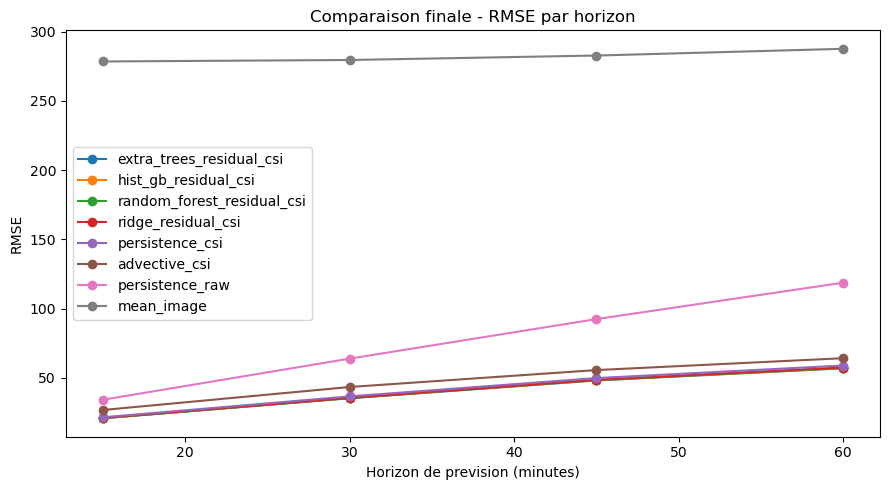

Modeles qui battent la persistance CSI:


,model,RMSE,MAE,skill_RMSE_vs_CSI
0,extra_trees_residual_csi,42.551652,23.737721,0.067652
1,hist_gb_residual_csi,42.734920,24.181061,0.059604
2,random_forest_residual_csi,42.748563,24.007016,0.059003
3,ridge_residual_csi,42.955433,25.222888,0.049874


In [9]:
if LOAD_SAVED_OUTPUTS:
    saved_predictions = load_saved_predictions(
        OUTPUT_DIR,
        strict_shape=tuple(val_target.shape),
    )
    print("Predictions chargees:", sorted(saved_predictions))

    # Les baselines recalculees localement servent de securite si elles ne sont pas dans le dossier.
    all_predictions = {**baseline_predictions, **saved_predictions}

    final_diagnostics = build_model_diagnostics(
        val_target,
        all_predictions,
        reference_name=MAIN_REFERENCE_NAME,
    )

    final_table = final_diagnostics["global"]
    display(final_table)
    display(final_diagnostics["by_horizon"].sort_values(["horizon_min", "RMSE"]))
    display(final_diagnostics["spatial_structure"].sort_values(["horizon_min", "RMSE_structure"]))

    fig, ax = plt.subplots(figsize=(9, 5))
    plot_models = list(final_table["model"].head(min(8, len(final_table))))
    for model_name in plot_models:
        h = final_diagnostics["by_horizon"].query("model == @model_name")
        ax.plot(h["horizon_min"], h["RMSE"], marker="o", label=model_name)
    ax.set_xlabel("Horizon de prevision (minutes)")
    ax.set_ylabel("RMSE")
    ax.set_title("Comparaison finale - RMSE par horizon")
    ax.legend()
    plt.tight_layout()
    plt.show()

    winners = final_table.query("model != @MAIN_REFERENCE_NAME and skill_RMSE_vs_CSI > 0")
    if len(winners):
        print("Modeles qui battent la persistance CSI:")
        display(winners[["model", "RMSE", "MAE", "skill_RMSE_vs_CSI"]])
    else:
        print("Aucun modele sauvegarde ne bat la persistance CSI.")
else:
    print("LOAD_SAVED_OUTPUTS=False: comparaison finale depuis artefacts sautee.")

## 8. Option: comparaison par cluster

Si tu veux conserver l'analyse par regime meteo dans le rendu final, elle peut aussi utiliser les predictions chargees.

In [10]:
if LOAD_SAVED_OUTPUTS and RUN_CLUSTERING:
    cluster_feature_candidates = [
        col for col in feature_names
        if any(token in col for token in ["CSI_mean", "CSI_std", "CSI_trend", "GHI_mean", "GHI_std", "flow_", "tex_"])
    ]
    cluster_feature_names = cluster_feature_candidates if len(cluster_feature_candidates) >= 3 else feature_names

    X_cluster_train = X_train_features[cluster_feature_names].to_numpy(dtype=np.float32)
    X_cluster_val = X_val_features[cluster_feature_names].to_numpy(dtype=np.float32)

    cluster_scaler = StandardScaler()
    X_cluster_train_scaled = cluster_scaler.fit_transform(X_cluster_train)
    X_cluster_val_scaled = cluster_scaler.transform(X_cluster_val)

    cluster_pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
    X_cluster_train_emb = cluster_pca.fit_transform(X_cluster_train_scaled)
    X_cluster_val_emb = cluster_pca.transform(X_cluster_val_scaled)

    kmeans = KMeans(n_clusters=2 if PROFILE == "dev" else 3, n_init=30, random_state=RANDOM_STATE)
    train_clusters = kmeans.fit_predict(X_cluster_train_emb)
    val_clusters = kmeans.predict(X_cluster_val_emb)

    cluster_frame = X_val_features.copy()
    cluster_frame["cluster"] = val_clusters
    csi_cols = [col for col in cluster_frame.columns if "phys_CSI_mean_t3" in col or "csi_last_frame_mean" in col]
    csi_label_col = csi_cols[0] if csi_cols else cluster_feature_names[0]
    cluster_summary = (
        cluster_frame
        .groupby("cluster")
        .agg(n=(csi_label_col, "size"), csi_level=(csi_label_col, "mean"))
        .sort_values("csi_level")
    )
    weather_names = ["couvert", "partiellement_nuageux", "ciel_clair", "tres_variable"]
    cluster_name_map = {cluster: weather_names[i] for i, cluster in enumerate(cluster_summary.index)}
    cluster_summary["regime"] = [cluster_name_map[idx] for idx in cluster_summary.index]
    display(cluster_summary.reset_index())

    best_model_name = final_table.iloc[0]["model"]
    cluster_perf = pd.concat(
        [
            metrics_by_cluster(
                val_target,
                all_predictions[MAIN_REFERENCE_NAME],
                val_clusters,
                MAIN_REFERENCE_NAME,
                cluster_name_map=cluster_name_map,
                reference_pred=all_predictions[MAIN_REFERENCE_NAME],
            ),
            metrics_by_cluster(
                val_target,
                all_predictions[best_model_name],
                val_clusters,
                best_model_name,
                cluster_name_map=cluster_name_map,
                reference_pred=all_predictions[MAIN_REFERENCE_NAME],
            ),
        ],
        ignore_index=True,
    )
    display(cluster_perf.sort_values(["cluster", "RMSE"]))
else:
    print("Analyse cluster sautee.")

,cluster,n,csi_level,regime
0,1,203,0.627753,couvert
1,2,142,0.895066,partiellement_nuageux
2,0,24,0.928063,ciel_clair


,model,cluster,regime,n,RMSE,MAE,bias,P90AE,nRMSE,skill_RMSE_vs_CSI
3,extra_trees_residual_csi,0,ciel_clair,24,29.855216,16.082264,-0.423934,45.596710,0.054438,9.666347e-02
0,persistence_csi,0,ciel_clair,24,31.411989,16.954576,4.061344,48.693253,0.057276,1.013467e-11
4,extra_trees_residual_csi,1,couvert,203,52.872573,33.658119,-4.149142,85.007942,0.186187,6.624357e-02
1,persistence_csi,1,couvert,203,54.715912,34.457394,-6.923198,88.583176,0.192678,3.340217e-12
5,extra_trees_residual_csi,2,partiellement_nuageux,142,23.623660,10.849627,-0.669380,30.780304,0.064962,6.963537e-02
2,persistence_csi,2,partiellement_nuageux,142,24.491794,12.154548,-0.498931,31.650919,0.067350,1.667089e-11


## Conclusion pratique

Ce notebook permet de ne plus melanger les environnements. Chaque run produit des predictions standardisees. Le rendu final recharge seulement les fichiers du dossier `OUTPUT_DIR` et recalcule toutes les metriques de comparaison.

Pour partager les outputs Colab avec VSCode, le plus simple est de mettre `OUTPUT_DIR` dans Google Drive, puis de telecharger ou synchroniser ce dossier dans le repo local avant la comparaison finale.